**SETUP**

In [1]:
import os, json, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
QUICK_TEST = False   # True = quick check on a small subset; False = full training
OUT = "/kaggle/working"
os.makedirs(f"{OUT}/figures", exist_ok=True)
os.makedirs(f"{OUT}/models", exist_ok=True)
tf.keras.utils.set_random_seed(SEED)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


**Load the splits from Phase 1**

In [2]:
DATA_DIR, SPLIT_DIR = None, None
for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root) == "color" and DATA_DIR is None:
        DATA_DIR = root
    if "train_split.csv" in files:
        SPLIT_DIR = root
print("Images:", DATA_DIR)
print("Splits:", SPLIT_DIR)

def load_split(name):
    d = pd.read_csv(f"{SPLIT_DIR}/{name}_split.csv")
    # rebuild paths in case Kaggle mounted the dataset at a different location
    d["path"] = d.apply(lambda r: os.path.join(DATA_DIR, r["class"], os.path.basename(r["path"])), axis=1)
    return d

train_df, val_df, test_df = load_split("train"), load_split("val"), load_split("test")
class_names = sorted(train_df["class"].unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES = len(class_names)

with open(f"{OUT}/models/class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

if QUICK_TEST:
    train_df = train_df.groupby("class").head(30)
    val_df = val_df.groupby("class").head(10)

assert os.path.exists(train_df["path"].iloc[0]), "Image paths are wrong"
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Classes: {NUM_CLASSES}")

Images: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color
Splits: /kaggle/input/notebooks/cyrinegraf/01-data-exploration
Train: 38013 | Val: 8146 | Test: 8146 | Classes: 38


**Data pipeline and class weights**

In [3]:
def make_dataset(d, shuffle=False):
    labels = d["class"].map(class_to_idx).values
    ds = tf.data.Dataset.from_tensor_slices((d["path"].values, labels))
    if shuffle:
        ds = ds.shuffle(len(d), seed=SEED)
    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        return img, label
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)

weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES),
                               y=train_df["class"].map(class_to_idx).values)
class_weight = dict(enumerate(weights))
print("Class weights range:", round(min(weights), 2), "to", round(max(weights), 2))

I0000 00:00:1790975779.671678      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790975779.676787      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Class weights range: 0.26 to 9.44


# **The three models**

In [4]:
def make_augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
    ], name="augmentation")

def build_custom_cnn():
    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = make_augmentation()(inputs)
    x = layers.Rescaling(1.0 / 255)(x)
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="custom_cnn"), None

def build_transfer(name):
    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = make_augmentation()(inputs)
    if name == "mobilenetv2":
        x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)   # MobileNetV2 expects values in [-1, 1]
        base = keras.applications.MobileNetV2(include_top=False, weights="imagenet",
                                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
    else:
        base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet",
                                                 input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=name), base

**Augmentation is inside the model.** It runs only during training and is automatically switched off at prediction time.

**Preprocessing is also inside the model:** rescaling for the CNN and MobileNetV2, while EfficientNet has its own built in. So the saved model accepts raw images (pixel values 0–255), which keeps the API in Phase 4 very simple.

**base.trainable = False:** we first freeze the pretrained network and train only the new classification head.

# **Training functions**

In [5]:
def train(model, epochs, lr):
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
    ]
    start = time.time()
    h = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                  class_weight=class_weight, callbacks=callbacks)
    return h.history, time.time() - start

def unfreeze_top(base, n_layers):
    base.trainable = True
    for layer in base.layers[:-n_layers]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False   # keep BatchNorm frozen during fine-tuning

E_CNN, E_HEAD, E_FT = (2, 1, 1) if QUICK_TEST else (15, 5, 10)
results, histories = [], {}

def run(name):
    keras.backend.clear_session()
    if name == "custom_cnn":
        model, _ = build_custom_cnn()
        hist, t = train(model, E_CNN, 1e-3)
    else:
        model, base = build_transfer(name)
        h1, t1 = train(model, E_HEAD, 1e-3)    # stage 1: train the head only
        unfreeze_top(base, 30)
        h2, t2 = train(model, E_FT, 1e-5)      # stage 2: fine-tune the top 30 layers
        hist = {k: h1[k] + h2[k] for k in h1 if k in h2}
        t = t1 + t2
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    path = f"{OUT}/models/{name}.keras"
    model.save(path)
    histories[name] = {k: [float(v) for v in vals] for k, vals in hist.items()}
    results.append({
        "model": name,
        "val_accuracy": round(val_acc, 4),
        "val_loss": round(val_loss, 4),
        "params_millions": round(model.count_params() / 1e6, 2),
        "train_minutes": round(t / 60, 1),
        "size_mb": round(os.path.getsize(path) / 1e6, 1),
    })
    print(results[-1])

**Two-stage transfer learning:**

1.Train only the new head, with a normal learning rate (1e-3).

2.Unfreeze the top 30 layers of the pretrained network and continue with a very small learning rate (1e-5), so we adapt the network without destroying what it learned on ImageNet.

**EarlyStopping** stops training when validation accuracy stops improving and keeps the best weights.

# **Train the three models**

In [6]:
run("custom_cnn")

Epoch 1/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 171s 136ms/step - accuracy: 0.6006 - loss: 1.3819 - val_accuracy: 0.5460 - val_loss: 1.6267 - learning_rate: 0.0010
Epoch 2/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 152s 128ms/step - accuracy: 0.8063 - loss: 0.6146 - val_accuracy: 0.6312 - val_loss: 1.4889 - learning_rate: 0.0010
Epoch 3/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 152s 128ms/step - accuracy: 0.8705 - loss: 0.3951 - val_accuracy: 0.8404 - val_loss: 0.5287 - learning_rate: 0.0010
Epoch 4/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 152s 128ms/step - accuracy: 0.8941 - loss: 0.3251 - val_accuracy: 0.7869 - val_loss: 0.7639 - learning_rate: 0.0010
Epoch 5/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 151s 127ms/step - accuracy: 0.9120 - loss: 0.2616 - val_accuracy: 0.8364 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 6/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 152s 128ms/step - accuracy: 0.9293 - loss: 0.2100 - val_accuracy: 0.6458 - val_loss: 1.5986 - learning_rate: 0.0010
{'model': 'custom_cnn', 'val_accuracy': 0.8404, 'val

In [7]:
run("mobilenetv2")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 84s 66ms/step - accuracy: 0.7919 - loss: 0.7956 - val_accuracy: 0.8925 - val_loss: 0.3805 - learning_rate: 0.0010
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 77s 65ms/step - accuracy: 0.8799 - loss: 0.3893 - val_accuracy: 0.9100 - val_loss: 0.2936 - learning_rate: 0.0010
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 77s 65ms/step - accuracy: 0.8935 - loss: 0.3370 - val_accuracy: 0.9206 - val_loss: 0.2630 - learning_rate: 0.0010
Epoch 4/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 77s 65ms/step - accuracy: 0.9024 - loss: 0.3087 - val_accuracy: 0.9181 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 5/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 77s 64ms/step - accuracy: 0.9025 - loss: 0.3064 - val_accuracy: 0.9268 - val_loss: 0.2317 - learning_rate: 0.0010
Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 92s 73ms/step - accuracy: 0.9201 - loss: 0.2459 - val_accuracy: 0.9385 - val_loss: 0.1869 - learning_rate: 1.0000e-05
Epoch 2/10
1188/

In [8]:
run("efficientnetb0")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


E0000 00:00:1790978014.536220      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 115s 90ms/step - accuracy: 0.8109 - loss: 0.8906 - val_accuracy: 0.9074 - val_loss: 0.3596 - learning_rate: 0.0010
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 104s 87ms/step - accuracy: 0.9035 - loss: 0.3675 - val_accuracy: 0.9287 - val_loss: 0.2626 - learning_rate: 0.0010
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 104s 87ms/step - accuracy: 0.9176 - loss: 0.2884 - val_accuracy: 0.9265 - val_loss: 0.2398 - learning_rate: 0.0010
Epoch 4/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 103s 87ms/step - accuracy: 0.9249 - loss: 0.2494 - val_accuracy: 0.9273 - val_loss: 0.2265 - learning_rate: 0.0010
Epoch 5/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 104s 88ms/step - accuracy: 0.9297 - loss: 0.2308 - val_accuracy: 0.9373 - val_loss: 0.1952 - learning_rate: 0.0010
Epoch 1/10


E0000 00:00:1790978546.606213      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 125s 97ms/step - accuracy: 0.9435 - loss: 0.1726 - val_accuracy: 0.9569 - val_loss: 0.1287 - learning_rate: 1.0000e-05
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 113s 95ms/step - accuracy: 0.9513 - loss: 0.1482 - val_accuracy: 0.9615 - val_loss: 0.1159 - learning_rate: 1.0000e-05
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 112s 94ms/step - accuracy: 0.9557 - loss: 0.1340 - val_accuracy: 0.9579 - val_loss: 0.1234 - learning_rate: 1.0000e-05
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 113s 95ms/step - accuracy: 0.9584 - loss: 0.1215 - val_accuracy: 0.9659 - val_loss: 0.1062 - learning_rate: 1.0000e-05
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 112s 95ms/step - accuracy: 0.9612 - loss: 0.1168 - val_accuracy: 0.9642 - val_loss: 0.1050 - learning_rate: 1.0000e-05
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 113s 95ms/step - accuracy: 0.9636 - loss: 0.1102 - val_accuracy: 0.9651 - val_loss: 0.1017 - learning_rate: 1.0000e-05
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 112

# **Curves and comparison table**

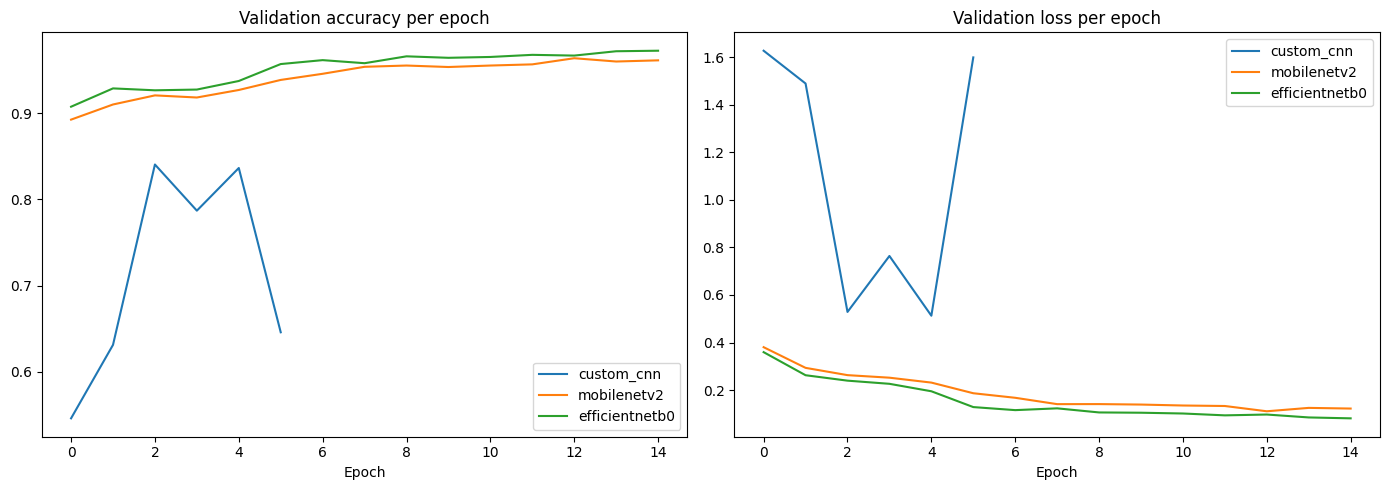

,model,val_accuracy,val_loss,params_millions,train_minutes,size_mb
0,custom_cnn,0.8404,0.5287,0.40,15.5,4.9
1,mobilenetv2,0.9637,0.1111,2.31,21.1,22.3
2,efficientnetb0,0.9724,0.0814,4.10,27.9,29.5


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    axes[0].plot(h["val_accuracy"], label=name)
    axes[1].plot(h["val_loss"], label=name)
axes[0].set_title("Validation accuracy per epoch")
axes[1].set_title("Validation loss per epoch")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/figures/training_curves.png", dpi=150)
plt.show()

results_df = pd.DataFrame(results)
results_df.to_csv(f"{OUT}/model_comparison.csv", index=False)
with open(f"{OUT}/histories.json", "w") as f:
    json.dump(histories, f)
results_df